In [279]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2 

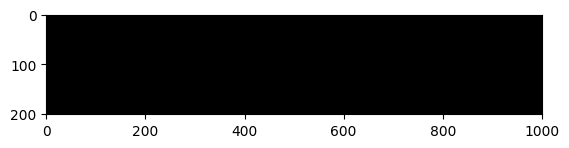

In [280]:
l = 1001
h = 201
qtd_pontos_versieira = 12
if qtd_pontos_versieira % 2 != 0:
    qtd_pontos_versieira += 1
tela = np.zeros(shape=(h, l, 3), dtype=np.uint8)

plt.imshow(tela)

In [281]:
cores = {
    "preto": (0, 0, 0),
    "branco": (255, 255, 255),
    "vermelho": (255, 0, 0),
    "verde": (0, 255, 0),
    "azul": (0, 0, 255),
    "amarelo": (255, 255, 0),
    "laranja": (255, 165, 0),
    "roxo": (128, 0, 128)
}

In [282]:
cor_fundo = cores["branco"]
cor_circunferencia = cores["preto"]
cor_trave = cores["verde"]
cor_ps = cores["laranja"]
cor_versieira = cores["vermelho"]

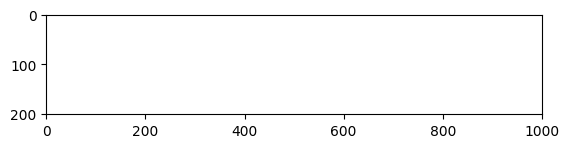

In [283]:
tela[:, :] = cor_fundo
plt.imshow(tela)

In [284]:
xc = (l - 1) // 2
yc = (h - 1) // 2
r = (h - 1) // 2
print(xc, yc, r)

500 100 100


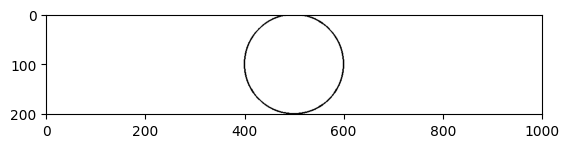

In [285]:
cv2.circle(tela, (xc, yc), r, cor_circunferencia, thickness=2)
plt.imshow(tela)

(500, 201)


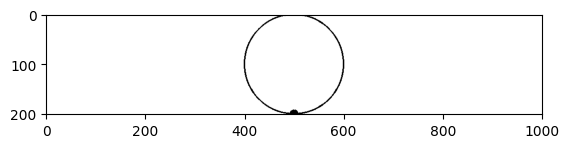

In [286]:
p1 = ((l - 1) // 2, h)
print(p1)
cv2.circle(tela, p1, 3, (0,0,0), thickness=12)
plt.imshow(tela)

In [287]:
# colecao da coordenada x dos pontos_dois

xp2 =np.linspace(start=0, stop=l - 1, num=qtd_pontos_versieira).round().astype(int)
print(xp2)

[   0   91  182  273  364  455  545  636  727  818  909 1000]


In [288]:
#print([0] * qtd_pontos_versieira)
display(list(zip(xp2, [0] * qtd_pontos_versieira)) )

[(np.int64(0), 0),
 (np.int64(91), 0),
 (np.int64(182), 0),
 (np.int64(273), 0),
 (np.int64(364), 0),
 (np.int64(455), 0),
 (np.int64(545), 0),
 (np.int64(636), 0),
 (np.int64(727), 0),
 (np.int64(818), 0),
 (np.int64(909), 0),
 (np.int64(1000), 0)]

In [289]:
#guardando oq ta na celula de cima dentor de uma variavel
pontos_dois = list(zip(xp2, [0] * qtd_pontos_versieira))

In [290]:
fc = lambda x : np.sqrt(r**2 - (x - xc)**2) + yc

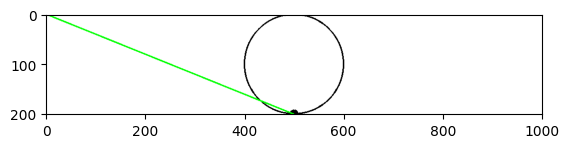

In [291]:
p2 = pontos_dois[0]
cv2.line(tela, p1, p2, cor_trave, thickness=2)
plt.imshow(tela)

In [292]:
a , b = np.polyfit(x=[p1[0], p2[0]], y=[p1[1], p2[1]], deg=1)
print(a, b)

0.40199999999999997 -4.993751933544652e-15


In [293]:
coef_a = a ** 2 + 1
coef_b = 2*a*b - 2*a*yc - 2*xc
coef_c = b**2 + yc**2 - 2*b*yc - r**2 +xc**2
print(coef_a, coef_b, coef_c)

1.161604 -1080.4 250000.0


In [294]:
#bhaskara

delta = coef_b ** 2 - 4 * coef_a * coef_c
print(delta)

x1 = (-coef_b + np.sqrt(delta)) / (2 * coef_a)
x2 = (-coef_b - np.sqrt(delta)) / (2 * coef_a)
print(x1, x2)

5660.160000000149
497.4302924452985 432.66292348715353


In [295]:
xs = max([x1,x2], key=lambda x: abs(x - p1[0]))

In [296]:
ys = a * xs + b
print(xs, ys)

432.66292348715353 173.9304952418357


In [297]:
ponto_versieira = (p2[0], int(ys))
print(ponto_versieira)

(np.int64(0), 173)


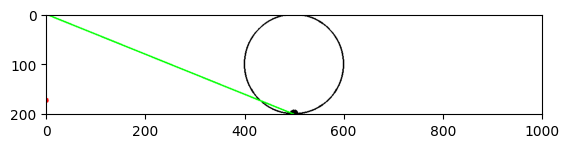

In [298]:
cv2.circle(tela, ponto_versieira, 5, cor_versieira, thickness=-1)
plt.imshow(tela)

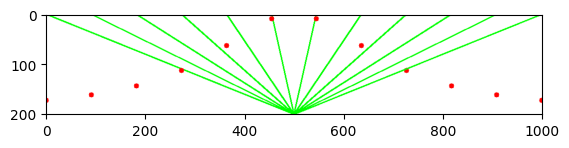

In [301]:
import numpy as np
import matplotlib.pyplot as plt 
import cv2


l = 1001
h = 201
qtd_pontos_versieira = 250
if qtd_pontos_versieira % 2 != 0:   
    qtd_pontos_versieira += 1
tela = np.zeros(shape=(h, l, 3), dtype=np.uint8)



cores = {
    "preto": (0, 0, 0),
    "branco": (255, 255, 255),
    "vermelho": (255, 0, 0),
    "verde": (0, 255, 0),
    "azul": (0, 0, 255),
    "amarelo": (255, 255, 0),
    "laranja": (255, 165, 0),
    "roxo": (128, 0, 128)
}


cor_fundo = cores["branco"]
cor_circunferencia = cores["preto"]
cor_trave = cores["verde"]
cor_ps = cores["laranja"]
cor_versieira = cores["vermelho"]

tela[:, :] = cor_fundo

xc = (l - 1) // 2
yc = (h - 1) // 2
r = (h - 1) // 2

cv2.circle(tela, ponto_versieira, 5, cor_versieira, thickness=-1)
plt.imshow(tela)


pontos_dois = list(zip(xp2, [0] * qtd_pontos_versieira))




for p2 in pontos_dois:
    cv2.line(tela, p1, p2, cor_trave, thickness=2)
    a , b = np.polyfit(x=[p1[0], p2[0]], y=[p1[1], p2[1]], deg=1)
    coef_a = a ** 2 + 1
    coef_b = 2*a*b - 2*a*yc - 2*xc
    coef_c = b**2 + yc**2 - 2*b*yc - r**2 +xc**2
    delta = coef_b ** 2 - 4 * coef_a * coef_c
    x1 = (-coef_b + np.sqrt(delta)) / (2 * coef_a)
    x2 = (-coef_b - np.sqrt(delta)) / (2 * coef_a)
    xs = max([x1,x2], key=lambda x: abs(x - p1[0]))
    ys = a * xs + b
    ponto_versieira = (p2[0], int(ys))
    cv2.circle(tela, ponto_versieira, 5, cor_versieira, thickness=-1)
plt.imshow(tela)

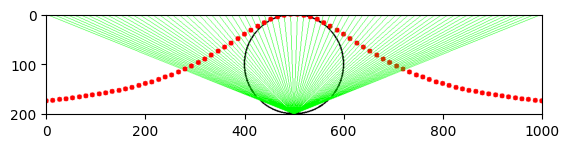

In [305]:
import cv2
import numpy as np
from matplotlib import pyplot as plt

l = 1001
h = 201
qtd_pontos_versiera = 75
if qtd_pontos_versiera % 2 != 0:
    qtd_pontos_versiera += 1

tela = np.zeros(
    shape=(h, l, 3), dtype=np.uint8
)

cores = {
    "preto": (0, 0, 0),
    "branco": (255, 255, 255),
    "vermelho": (255, 0, 0),
    "verde": (0, 255, 0),
    "azul": (0, 0, 255),
    "amarelo": (255, 255, 0),
    "laranja": (255, 165, 0),
    "roxo": (128, 0, 128)
}

cor_fundo = cores["branco"]
cor_circunferencia = cores["preto"]
cor_trave = cores["verde"]
cor_ps = cores["laranja"]
cor_versiera = cores["vermelho"]

tela[:, :] = cor_fundo

xc = (l - 1) // 2
yc = (h - 1) // 2
r = (h - 1) // 2

cv2.circle(tela, (xc, yc), r, cor_circunferencia, 2)

p1 = (
    (l - 1) // 2,
    h
)
cv2.circle(tela, p1, 10, cores["preto"], -1)


xp2 = np.linspace(start=0, stop=l - 1, num=qtd_pontos_versiera). \
        round(0). \
        astype(int)
pontos_dois = list(zip(xp2,[0] * qtd_pontos_versiera))
for p2 in pontos_dois:
    # print(p2)
    cv2.line(tela, p1, p2, cor_trave, 1)

    a, b = np.polyfit(
        x=[p1[0], p2[0]],
        y=[p1[1], p2[1]],
        deg=1
    )

    coef_a = a**2 + 1
    coef_b = 2*a*b - 2*a*yc - 2*xc
    coef_c = b**2 + yc**2 - 2*b*yc - r**2 + xc**2

    delta = coef_b**2 - 4*coef_a*coef_c
    x1 = (-coef_b + np.sqrt(delta)) / (2 * coef_a)
    x2 = (-coef_b - np.sqrt(delta)) / (2 * coef_a)

    xs = max([x1, x2], key=lambda x: abs(x - p1[0]))
    ys = a * xs + b

    ponto_versiera = (p2[0], int(round(ys, 0)))
    cv2.circle(tela, ponto_versiera, 5, cor_versiera, -1)
plt.imshow(tela);



